In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/drive/MyDrive/spam.csv', encoding='latin1')

In [3]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Shape:", df.shape)

df.head()

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


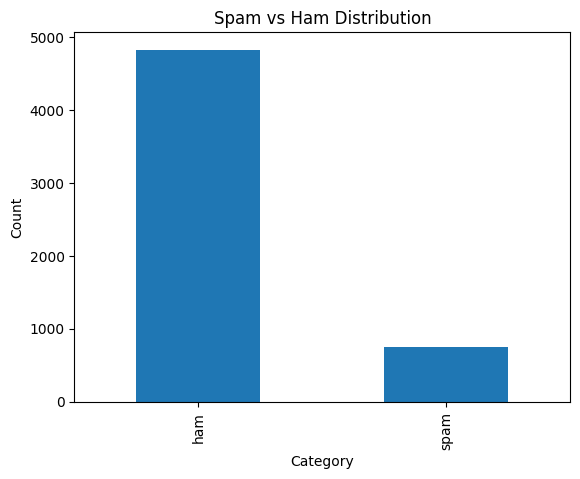

In [5]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [6]:
df['length'] = df['message'].apply(len)

print("Average Length:", df['length'].mean())

df.groupby('label')['length'].mean()

Average Length: 80.11880832735105


,length
label,
ham,71.023627
spam,138.866131


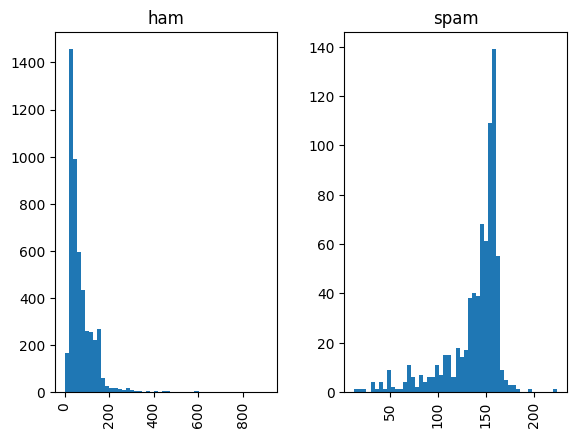

In [7]:
df.hist(column='length', by='label', bins=50)
plt.show()

In [8]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

all_words = ' '.join(df['message']).lower().split()

filtered_words = [word for word in all_words if word not in stop_words]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('u', 991), ('call', 557), ('2', 453), ('ur', 379), ('get', 375), ('&lt;#&gt;', 276), ('go', 262), ('4', 249), ('.', 235), ('got', 234), ('like', 234), ('know', 230), ('free', 228), ('come', 217), ('good', 199), ('?', 187), ('send', 186), ('want', 182), ('text', 175), ('time', 169)]


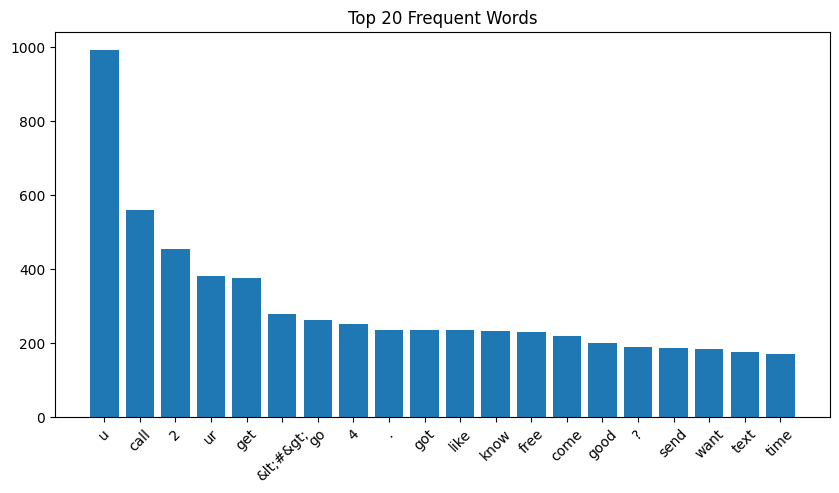

In [9]:
word_freq = Counter(filtered_words)
common_words = word_freq.most_common(20)
print(common_words)
words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.show()

In [10]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalnum()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [12]:
import nltk
nltk.download('punkt_tab', quiet=True)
df['cleaned_message'] = df['message'].apply(preprocess)
df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

X_bow = bow.fit_transform(df['cleaned_message'])

print("BoW Shape:", X_bow.shape)

BoW Shape: (5572, 7493)


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(df['cleaned_message'])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (5572, 7493)


In [15]:
print("BoW Features:", len(bow.vocabulary_))
print("TF-IDF Features:", len(tfidf.vocabulary_))

BoW Features: 7493
TF-IDF Features: 7493


In [16]:
import numpy as np

def calculate_sparsity(X):
    return 1.0 - (X.count_nonzero() / (X.shape[0] * X.shape[1]))

print("BoW Sparsity:", calculate_sparsity(X_bow))
print("TF-IDF Sparsity:", calculate_sparsity(X_tfidf))

BoW Sparsity: 0.9989362888492529
TF-IDF Sparsity: 0.9989362888492529


In [17]:
from sklearn.model_selection import train_test_split

X = X_tfidf   # Use TF-IDF features
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9372197309417041


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[959   6]
 [ 64  86]]


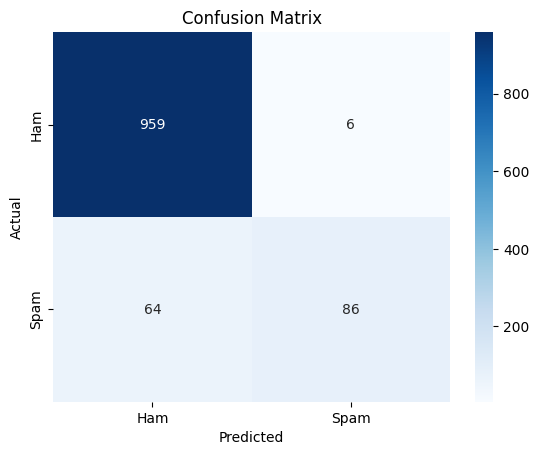

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [24]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

In [25]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='spam')
    rec = recall_score(y_test, y_pred, pos_label='spam')
    f1 = f1_score(y_test, y_pred, pos_label='spam')

    results.append([name, acc, prec, rec, f1])

In [26]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.962332   1.000000  0.720000  0.837209
1  Logistic Regression  0.937220   0.934783  0.573333  0.710744
2                  SVM  0.968610   0.983193  0.780000  0.869888


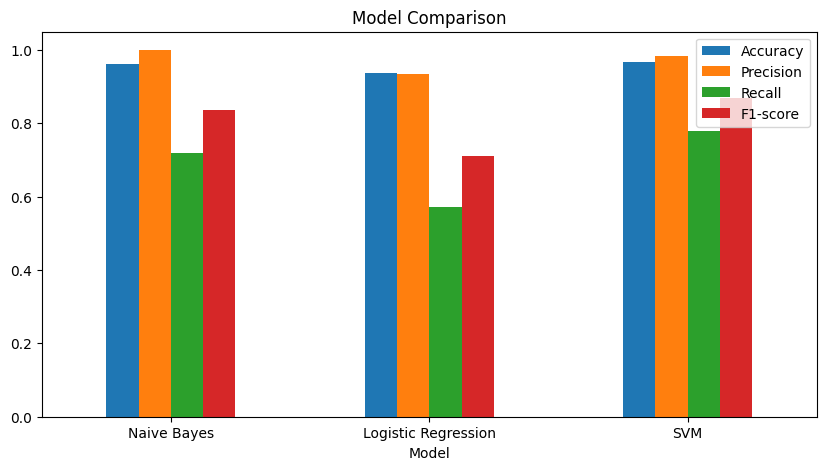

In [27]:
results_df.set_index("Model").plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000),
                       param_grid_lr,
                       cv=5,
                       scoring='f1')

grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

Best LR Params: {'C': 0.01}
Best LR Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


In [29]:
from sklearn.svm import SVC

param_grid_svm = {
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(),
                        param_grid_svm,
                        cv=5,
                        scoring='f1')

grid_svm.fit(X_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

Best SVM Params: {'kernel': 'linear'}
Best SVM Score: nan


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bigram = TfidfVectorizer(ngram_range=(1,2))
X_bigram = tfidf_bigram.fit_transform(df['cleaned_message'])

In [31]:
tfidf_trigram = TfidfVectorizer(ngram_range=(1,3))
X_trigram = tfidf_trigram.fit_transform(df['cleaned_message'])

In [32]:
!pip install gensim
from gensim.models import Word2Vec

sentences = [msg.split() for msg in df['cleaned_message']]

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.5 MB/s eta 0:00:00


In [33]:
import numpy as np

def sentence_vector(sentence):
    words = sentence.split()
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_w2v = np.array([sentence_vector(msg) for msg in df['cleaned_message']])

In [34]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, df['label'], test_size=0.2, random_state=42
)

model.fit(X_train_w2v, y_train)

SVC()

In [35]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['message'].apply(get_sentiment)

In [36]:
import numpy as np

X_combined = np.hstack((X_tfidf.toarray(), df['sentiment'].values.reshape(-1,1)))

In [37]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [38]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['entities'] = df['message'].apply(extract_entities)

df[['message', 'entities']].head()

,message,entities
0,"Go until jurong point, crazy.. Available only ...","[(Cine, PERSON)]"
1,Ok lar... Joking wif u oni...,[]
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[(2, CARDINAL), (FA Cup, EVENT), (21st May 200..."
3,U dun say so early hor... U c already then say...,"[(U dun, PRODUCT)]"
4,"Nah I don't think he goes to usf, he lives aro...",[]


In [40]:
from nltk import pos_tag
from collections import Counter
import nltk

nltk.download('averaged_perceptron_tagger_eng')

def get_pos(text):
    return pos_tag(text.split())

df['pos_tags'] = df['cleaned_message'].apply(get_pos)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [41]:
nouns = []
verbs = []

for tags in df['pos_tags']:
    for word, tag in tags:
        if tag.startswith('NN'):
            nouns.append(word)
        elif tag.startswith('VB'):
            verbs.append(word)

print("Top Nouns:", Counter(nouns).most_common(10))
print("Top Verbs:", Counter(verbs).most_common(10))

Top Nouns: [('call', 455), ('gt', 271), ('day', 242), ('time', 241), ('u', 216), ('lt', 195), ('today', 173), ('r', 159), ('home', 154), ('text', 152)]
Top Verbs: [('go', 293), ('get', 265), ('got', 246), ('know', 239), ('come', 187), ('going', 173), ('want', 156), ('take', 135), ('say', 117), ('see', 109)]


In [42]:
from collections import defaultdict

bigram_model = defaultdict(list)

for sentence in df['cleaned_message']:
    words = sentence.split()
    for i in range(len(words)-1):
        bigram_model[words[i]].append(words[i+1])

In [46]:
import random

def predict_next(word):
    if word in bigram_model:
        return random.choice(bigram_model[word])
    return "No prediction"

print(predict_next("win"))

80086
